# 08A: DIJKSTRA ROUTING (HYBRID PATCHWORK APPROACH)

This notebook finds the hottest and coolest pedestrian routes using Dijkstra's algorithm with a hybrid cost surface. The hybrid approach merges GSV-based predictions (high fidelity in sampled wards) with raster-only predictions (full coverage).

In [ ]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

import os
from pathlib import Path

# Set working directory to project folder.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/hot_hem"
os.chdir(BASE_DIR)

MODEL_DIR = Path("models")
DIAGNOSTICS_DIR = MODEL_DIR / "diagnostics"

print(f"Working directory: {BASE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Colab Notebooks/hot_hem


## IMPORT SETUP

In [ ]:
!pip install osmnx

from pathlib import Path
import pickle
import warnings
from scipy.ndimage import gaussian_filter
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import rasterio
from rasterio import features
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from scipy.interpolate import griddata
import networkx as nx
import osmnx as ox
from shapely.geometry import Point, LineString, box
import random
import heapq
import folium
from shapely.geometry import LineString
warnings.filterwarnings("ignore")

## PATH CONFIGURATION

In [ ]:
# Input paths.
BOUNDARY_FILE = Path("data/inputs/boundaries/aoi_wards.geojson")
NETWORK_FILE = Path("data/processing/network/network.graphml")
FULL_MODEL_FILE = Path("models/xgboost_full_model.pkl")
DEPLOYMENT_MODEL_FILE = Path("models/xgboost_deployment_model.pkl")
GSV_FEATURES_FILE = Path("data/outputs/features/gsv_with_raster_features.csv")
NETWORK_FEATURES_FILE = Path("data/outputs/features/network_nodes_with_raster_features.csv")

# Output paths.
OUT_DIR = Path("data/outputs/routing")
OUT_DIR.mkdir(parents = True, exist_ok = True)

PRED_RASTER_ONLY = OUT_DIR / "pred_raster_only.tif"
PRED_GSV = OUT_DIR / "pred_gsv.tif"
HYBRID_RASTER = OUT_DIR / "hybrid_cost_surface.tif"
HOTTEST_ROUTE = OUT_DIR / "hottest_route_hybrid.geojson"

print("PATH CONFIGURATION")
print(f"Boundary file: {BOUNDARY_FILE}")
print(f"Network file: {NETWORK_FILE}")
print(f"Output directory: {OUT_DIR}")

PATH CONFIGURATION
Boundary file: data/inputs/boundaries/aoi_wards.geojson
Network file: data/processing/network/network.graphml
Output directory: data/outputs/routing


## LOAD STUDY AREA BOUNDARIES

In [ ]:
# Load ward boundaries.
gdf_wards_original = gpd.read_file(BOUNDARY_FILE)

print(f"Loaded {len(gdf_wards_original)} ward boundaries.")
print(f"Columns: {list(gdf_wards_original.columns)}")
print(f"CRS: {gdf_wards_original.crs}")

# Apply 500m buffer to match network extent.
# First convert to projected CRS for accurate buffering.
gdf_wards_utm = gdf_wards_original.to_crs("EPSG:32648")  # UTM Zone 48N for HCMC.
gdf_wards_buffered = gdf_wards_utm.copy()
gdf_wards_buffered["geometry"] = gdf_wards_buffered.geometry.buffer(500)
gdf_wards = gdf_wards_buffered.to_crs("EPSG:4326")

# Union all geometries.
study_area_union = gdf_wards.unary_union

# Convert back to GeoDataFrame.
gdf_study_area = gpd.GeoDataFrame(geometry=[study_area_union], crs=gdf_wards.crs)

print(f"Buffered wards CRS: {gdf_wards.crs}")
gdf_wards.head()

# Define GSV-sampled wards (high fidelity areas).
# These are wards where GSV imagery was collected.
GSV_WARDS = [
    "Ben Thanh",
    "Co Giang",
    "Thao Dien",
    "An Khanh",
    "Ward 5",
    "Ward 6"
]

# Identify ward column name.
ward_col = None
for col in ["ward", "Ward", "name", "NAME", "ten_phuong"]:
    if col in gdf_wards.columns:
        ward_col = col
        break

if ward_col:
    print(f"Ward column: {ward_col}")
    print(f"Available wards: {gdf_wards[ward_col].unique()}")
else:
    print("Ward column not found. Using all boundaries.")

# Get study area bounds.
total_bounds = gdf_wards.total_bounds
minx, miny, maxx, maxy = total_bounds

print("STUDY AREA BOUNDS (with 500m buffer)")
print(f"Min X (lon): {minx:.6f}")
print(f"Max X (lon): {maxx:.6f}")
print(f"Min Y (lat): {miny:.6f}")
print(f"Max Y (lat): {maxy:.6f}")

Loaded 37 ward boundaries.
Columns: ['OBJECTID', 'COUNTRY', 'ENGNAME', 'NAME_1', 'ENGNAME_1', 'NAME_2', 'ENGNAME_2', 'NAME_3', 'ENGNAME_3', 'TYPE_3', 'ENGTYPE_3', 'Shape_Length', 'Shape_Area', 'geometry']
CRS: EPSG:4326
Buffered wards CRS: EPSG:4326
Ward column not found. Using all boundaries.
STUDY AREA BOUNDS (with 500m buffer)
Min X (lon): 106.589987
Max X (lon): 106.814665
Min Y (lat): 10.685335
Max Y (lat): 10.824288


## LOAD TRAINED MODELS

In [ ]:
# Load full model (GSV + raster features).
with open(FULL_MODEL_FILE, "rb") as f:
    full_model_data = pickle.load(f)

model_full = full_model_data["model"]
features_full = full_model_data["features"]

print("FULL MODEL (GSV + RASTER)")
print(f"Number of features: {len(features_full)}")
print(f"CV R2: {full_model_data.get('cv_r2', 'N/A')}")

# Load deployment model (raster-only features).
with open(DEPLOYMENT_MODEL_FILE, "rb") as f:
    deploy_model_data = pickle.load(f)

model_deploy = deploy_model_data["model"]
features_deploy = deploy_model_data["features"]

print("DEPLOYMENT MODEL (RASTER ONLY)")
print(f"Number of features: {len(features_deploy)}")
print(f"CV R2: {deploy_model_data.get('cv_r2', 'N/A')}")
print(f"Features: {features_deploy}")

FULL MODEL (GSV + RASTER)
Number of features: 18
CV R2: 0.4752946306725647
DEPLOYMENT MODEL (RASTER ONLY)
Number of features: 11
CV R2: 0.4035860965951631
Features: ['ndvi', 'emissivity', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy', 'elevation_m', 'sky_view_factor', 'landcover_class']


## LOAD FEATURE DATA

In [ ]:
# Load GSV features for high-fidelity predictions.
df_gsv = pd.read_csv(GSV_FEATURES_FILE)

print(f"Loaded {len(df_gsv)} GSV sample points.")
print(f"Columns: {list(df_gsv.columns)[:10]}")
df_gsv.head()

# Load network node features for raster-only predictions.
df_network = pd.read_csv(NETWORK_FEATURES_FILE)

print(f"Loaded {len(df_network)} network nodes.")
print(f"Columns: {list(df_network.columns)[:10]}")
df_network.head()

Loaded 20402 GSV sample points.
Columns: ['uid', 'lat', 'lon', 'heading', 'pct_other', 'pct_vegetation', 'pct_sky', 'pct_building', 'pct_pavement_road', 'pct_water']
Loaded 28445 network nodes.
Columns: ['osmid', 'y', 'x', 'street_count', 'highway', 'ref', 'railway', 'geometry', 'lon', 'lat']


,osmid,y,x,street_count,highway,ref,railway,geometry,lon,lat,...,emissivity,palsar_hh_db,palsar_hv_db,palsar_hv_hh_ratio,palsar_glcm_contrast,palsar_glcm_homogeneity,palsar_glcm_energy,elevation_m,sky_view_factor,landcover_class
0,366367367,10.813901,106.732449,1,NaN,NaN,NaN,POINT (106.7324492 10.8139013),106.732449,10.813901,...,2.7385,-6.660599,-10.774033,1.617577,6199.80,0.031244,0.158114,10.0,0.999971,2.0
1,366368182,10.742144,106.670913,3,NaN,NaN,NaN,POINT (106.6709134 10.7421444),106.670913,10.742144,...,2.6601,2.644283,-11.333757,-4.286137,3650.35,0.008234,0.165831,9.0,0.998736,2.0
2,366368194,10.790241,106.709544,3,NaN,NaN,NaN,POINT (106.7095438 10.7902412),106.709544,10.790241,...,2.7238,5.584384,-0.062562,-0.011203,2781.00,0.007803,0.158114,7.0,0.993674,2.0
3,366368313,10.754628,106.684140,4,NaN,NaN,NaN,POINT (106.6841396 10.7546276),106.684140,10.754628,...,2.7826,3.691487,-10.945781,-2.965141,3170.60,0.107993,0.165831,12.0,0.999859,2.0
4,366368540,10.742907,106.672759,4,NaN,NaN,NaN,POINT (106.6727592 10.742907),106.672759,10.742907,...,2.6605,7.113308,-10.508171,-1.477255,4261.00,0.003137,0.158114,6.0,0.990122,2.0


## GENERATE PREDICTIONS

In [ ]:
# Generate raster-only predictions for all network nodes.
# Extract features for deployment model.
X_deploy = df_network[features_deploy].copy()

# Predict LST using raster-only model.
df_network["pred_raster_only"] = model_deploy.predict(X_deploy)

print(f"Raster-only predictions: min = {df_network['pred_raster_only'].min():.2f}, max = {df_network['pred_raster_only'].max():.2f}")

# Generate GSV-based predictions for GSV sample points.
# Check which features are available.
available_features_full = [f for f in features_full if f in df_gsv.columns]
print(f"Available features: {len(available_features_full)} / {len(features_full)}")

# If not all features available, use deployment model for GSV points too.
if len(available_features_full) < len(features_full):
    print("Using deployment model features for GSV predictions.")
    X_gsv = df_gsv[features_deploy].copy()
    df_gsv["pred_gsv"] = model_deploy.predict(X_gsv)
else:
    X_gsv = df_gsv[features_full].copy()
    df_gsv["pred_gsv"] = model_full.predict(X_gsv)

print(f"GSV predictions: min = {df_gsv['pred_gsv'].min():.2f}, max = {df_gsv['pred_gsv'].max():.2f}")

Raster-only predictions: min = 37.33, max = 44.04
Available features: 18 / 18
GSV predictions: min = 35.45, max = 45.65


## CREATE PREDICTION RASTERS

In [ ]:
# Define raster parameters.
RESOLUTION = 0.0001  # Approximately 10 meters at equator.
BUFFER = 0.001  # Small buffer around study area.

# Calculate raster dimensions.
raster_minx = minx - BUFFER
raster_maxx = maxx + BUFFER
raster_miny = miny - BUFFER
raster_maxy = maxy + BUFFER

width = int((raster_maxx - raster_minx) / RESOLUTION)
height = int((raster_maxy - raster_miny) / RESOLUTION)

print("RASTER PARAMETERS")
print(f"Resolution: {RESOLUTION} degrees.")
print(f"Width: {width} pixels.")
print(f"Height: {height} pixels.")

# Create transform.
transform = from_bounds(raster_minx, raster_miny, raster_maxx, raster_maxy, width, height)

# Create coordinate grid.
x_coords = np.linspace(raster_minx, raster_maxx, width)
y_coords = np.linspace(raster_maxy, raster_miny, height)  # Reversed for image coordinates.
xx, yy = np.meshgrid(x_coords, y_coords)

print(f"Grid Shape: {xx.shape}.")

# Interpolate raster-only predictions to grid.
# Get coordinates and values.
points_deploy = df_network[["lon", "lat"]].values
values_deploy = df_network["pred_raster_only"].values

# Remove NaN values.
valid_mask = ~np.isnan(values_deploy)
points_deploy = points_deploy[valid_mask]
values_deploy = values_deploy[valid_mask]

print(f"Valid points for interpolation: {len(points_deploy)}.")

# Interpolate to grid.
grid_deploy = griddata(
    points_deploy,
    values_deploy,
    (xx, yy),
    method = "linear",
    fill_value = np.nan
)

# Fill remaining NaN with nearest neighbor.
nan_mask = np.isnan(grid_deploy)
if nan_mask.any():
    grid_deploy_nearest = griddata(
        points_deploy,
        values_deploy,
        (xx, yy),
        method = "nearest"
    )
    grid_deploy[nan_mask] = grid_deploy_nearest[nan_mask]

print(f"Raster-Only Grid: min = {np.nanmin(grid_deploy):.2f}, max = {np.nanmax(grid_deploy):.2f}.")

# Save raster-only prediction raster.
print(f"Saving raster-only predictions to {PRED_RASTER_ONLY}.")

with rasterio.open(
    PRED_RASTER_ONLY,
    "w",
    driver = "GTiff",
    height = height,
    width = width,
    count = 1,
    dtype = "float32",
    crs = CRS.from_epsg(4326),
    transform = transform,
    nodata = np.nan
) as dst:
    dst.write(grid_deploy.astype("float32"), 1)

# Interpolate GSV predictions to grid.
# Get coordinates and values.
points_gsv = df_gsv[["lon", "lat"]].values
values_gsv = df_gsv["pred_gsv"].values

# Remove NaN values.
valid_mask_gsv = ~np.isnan(values_gsv)
points_gsv = points_gsv[valid_mask_gsv]
values_gsv = values_gsv[valid_mask_gsv]

print(f"Valid GSV points for interpolation: {len(points_gsv)}.")

# Interpolate to grid (linear only, NaN outside convex hull).
grid_gsv = griddata(
    points_gsv,
    values_gsv,
    (xx, yy),
    method = "linear",
    fill_value = np.nan
)

print(f"GSV Grid: valid pixels = {np.sum(~np.isnan(grid_gsv))}, NaN pixels = {np.sum(np.isnan(grid_gsv))}.")

# Create GSV ward mask to limit GSV predictions to sampled wards only.
# Create mask raster for GSV wards.
gsv_ward_mask = np.zeros((height, width), dtype = bool)

if ward_col:
    gsv_wards_gdf = gdf_wards[gdf_wards[ward_col].isin(GSV_WARDS)]

    if len(gsv_wards_gdf) > 0:
        # Check each pixel if it falls within GSV wards.
        gsv_union = gsv_wards_gdf.unary_union

        for i in range(height):
            for j in range(width):
                pt = Point(xx[i, j], yy[i, j])
                if gsv_union.contains(pt):
                    gsv_ward_mask[i, j] = True

        print(f"GSV ward mask: {np.sum(gsv_ward_mask)} pixels inside GSV wards.")
    else:
        print("No GSV wards found in boundary file. Using interpolation extent.")
        gsv_ward_mask = ~np.isnan(grid_gsv)
else:
    # Use interpolation extent as mask.
    gsv_ward_mask = ~np.isnan(grid_gsv)

# Apply mask to GSV grid.
grid_gsv_masked = np.where(gsv_ward_mask, grid_gsv, np.nan)

print(f"Masked GSV Grid: Valid Pixels = {np.sum(~np.isnan(grid_gsv_masked))}.")

# Save GSV prediction raster.
print(f"Saving GSV predictions to {PRED_GSV}.")

with rasterio.open(
    PRED_GSV,
    "w",
    driver = "GTiff",
    height = height,
    width = width,
    count = 1,
    dtype = "float32",
    crs = CRS.from_epsg(4326),
    transform = transform,
    nodata = np.nan
) as dst:
    dst.write(grid_gsv_masked.astype("float32"), 1)

RASTER PARAMETERS
Resolution: 0.0001 degrees.
Width: 2266 pixels.
Height: 1409 pixels.
Grid Shape: (1409, 2266).
Valid points for interpolation: 28445.
Raster-Only Grid: min = 37.38, max = 44.04.
Saving raster-only predictions to data/outputs/routing/pred_raster_only.tif.
Valid GSV points for interpolation: 20402.
GSV Grid: valid pixels = 397269, NaN pixels = 2795525.
Masked GSV Grid: Valid Pixels = 397269.
Saving GSV predictions to data/outputs/routing/pred_gsv.tif.


## CREATE HYBRID COST SURFACE

In [ ]:
# Unified polygon.
study_poly = gdf_study_area.geometry.iloc[0]

# Raster mask: 1 = inside study area, 0 = outside.
study_mask = features.rasterize(
    [(study_poly, 1)],
    out_shape = (height, width),
    transform = transform,
    fill = 0,
    dtype = "uint8"
)

print(f"Pixels inside study area: {study_mask.sum()}.")

# Mask for raster only and GSV.
grid_deploy_masked = np.where(study_mask == 1, grid_deploy, np.nan)

grid_gsv_masked = np.where(study_mask == 1, grid_gsv_masked, np.nan)

hybrid_surface = np.where(
    np.isnan(grid_gsv_masked),
    grid_deploy_masked,
    grid_gsv_masked
)

# Apply mask one more time to be safe.
hybrid_surface = np.where(study_mask == 1, hybrid_surface, np.nan)

print(f"Hybrid raster min/max: {np.nanmin(hybrid_surface):.2f} / {np.nanmax(hybrid_surface):.2f}.")

# Create mask.
valid_mask = ~np.isnan(hybrid_surface)

# Fill NaN temporarily with zeros.
filled = np.where(valid_mask, hybrid_surface, 0)

# Gaussian filter to values and mask.
sigma = 4
smooth_values = gaussian_filter(filled, sigma = sigma)
smooth_mask   = gaussian_filter(valid_mask.astype(float), sigma = sigma)

# Normalize.
smooth = smooth_values / smooth_mask
smooth[~valid_mask] = np.nan  # Restore NaN outside valid region.

Pixels inside study area: 969060.
Hybrid raster min/max: 35.73 / 45.56.


## VISUALIZE HYBRID COST SURFACE

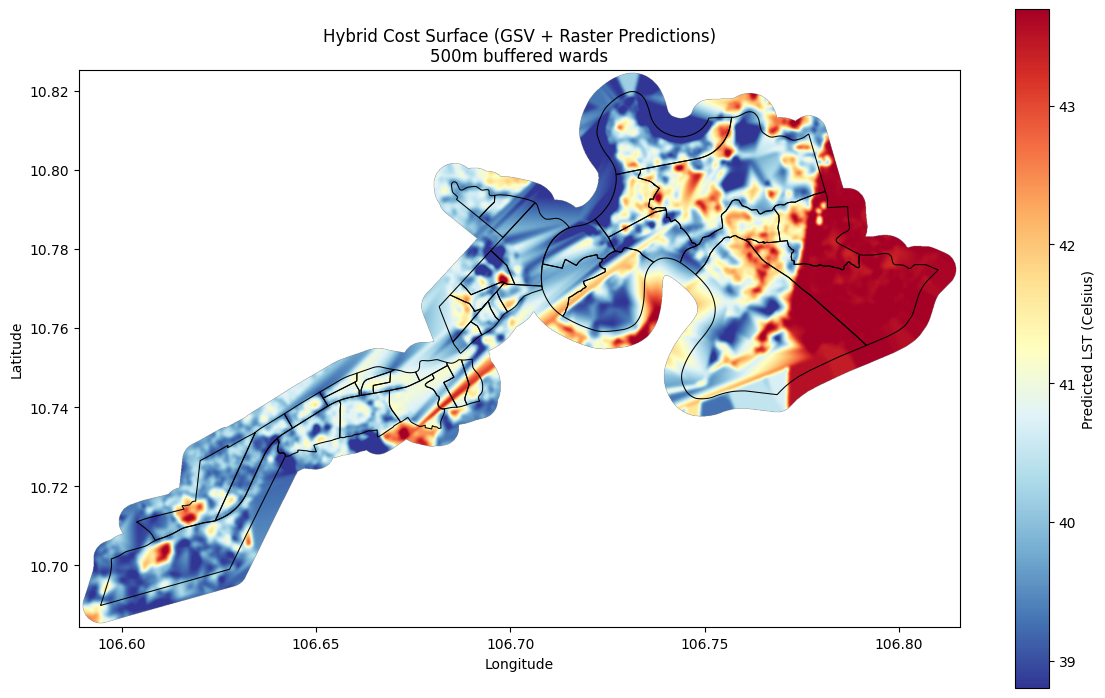

(1409, 2266)
Total Pixels: 3192794


In [ ]:
# Visualize hybrid cost surface with study area overlay.
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot hybrid surface.
im = ax.imshow(
    smooth,
    extent = [raster_minx, raster_maxx, raster_miny, raster_maxy],
    cmap = "RdYlBu_r",
    vmin = np.nanpercentile(smooth, 5),
    vmax = np.nanpercentile(smooth, 95),
    origin = "upper"
)

# Overlay ward boundaries.
gdf_wards_original.boundary.plot(
    ax = ax,
    color = "black",
    linewidth = 0.75,
    alpha = 1
)

cbar = plt.colorbar(im, ax = ax, label = "Predicted LST (Celsius)", shrink = 0.7)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Hybrid Cost Surface (GSV + Raster Predictions)\n500m buffered wards")

plt.tight_layout()
plt.show()

with rasterio.open(
    HYBRID_RASTER,
    "w",
    driver = "GTiff",
    height = height,
    width = width,
    count = 1,
    dtype = "float32",
    crs = CRS.from_epsg(4326),
    transform = transform,
    nodata = np.nan
) as dst:
    dst.write(hybrid_surface.astype("float32"), 1)

print(hybrid_surface.shape)
print("Total Pixels:", hybrid_surface.size)

## LOAD NETWORK GRAPH

In [ ]:
# Load network graph.
if NETWORK_FILE.exists():
    G = ox.load_graphml(NETWORK_FILE)
    print(f"Loaded network from file: {len(G.nodes)} nodes, {len(G.edges)} edges.")
else:
    # Download network if not available.
    print("Network file not found. Downloading from OSM.")
    study_area = gdf_wards.unary_union
    G = ox.graph_from_polygon(study_area, network_type = "walk")
    ox.save_graphml(G, NETWORK_FILE)
    print(f"Downloaded network: {len(G.nodes)} nodes, {len(G.edges)} edges.")

# Convert to undirected graph for routing.
G_undirected = G.to_undirected()

print(f"Undirected graph: {len(G_undirected.nodes)} nodes, {len(G_undirected.edges)} edges.")

# Get node coordinates.
node_coords = {node: (data["x"], data["y"]) for node, data in G_undirected.nodes(data = True)}

print(f"Extracted coordinates for {len(node_coords)} nodes.")

Loaded network from file: 28445 nodes, 74710 edges.
Undirected graph: 28445 nodes, 37443 edges.
Extracted coordinates for 28445 nodes.


## ASSIGN HEAT WEIGHTS TO EDGES

In [ ]:
# Get node coordinates in vectorized arrays.
node_ids = np.array(list(node_coords.keys()))
lons = np.array([node_coords[n][0] for n in node_ids])
lats = np.array([node_coords[n][1] for n in node_ids])

# Convert lon/lat to raster row/col.
cols = ((lons - raster_minx) / RESOLUTION).astype(int)
rows = ((raster_maxy - lats) / RESOLUTION).astype(int)

# Clip to bounds.
rows = np.clip(rows, 0, height - 1)
cols = np.clip(cols, 0, width - 1)

# Sample hybrid raster at all nodes.
lst_vals = hybrid_surface[rows, cols]

# Replace NaNs with raster mean.
hybrid_mean = np.nanmean(hybrid_surface)
lst_vals = np.where(np.isnan(lst_vals), hybrid_mean, lst_vals)

# Build dictionary {node: LST}.
node_lst = dict(zip(node_ids, lst_vals))

print(f"Assigned LST to {len(node_lst)} nodes.")
print(f"LST Range: {lst_vals.min():.2f} – {lst_vals.max():.2f}")

# Assign edge weights, avg LST and inverted heat cost.
lst_min = lst_vals.min()
lst_max = lst_vals.max()

# Get node LSTs for lookup.
node_lst_lookup = node_lst

for u, v, data in G_undirected.edges(data = True):
    lst_u = node_lst_lookup[u]
    lst_v = node_lst_lookup[v]

    # Average LST on edge.
    avg_lst = (lst_u + lst_v) / 2

    # Inverted heat cost: hotter = lower cost.
    heat_cost = lst_max - avg_lst + 0.01

    data["avg_lst"] = avg_lst
    data["heat_cost"] = heat_cost

print(f"avg_lst range: {min(node_lst.values()):.2f} – {max(node_lst.values()):.2f}.")
print(f"heat_cost range: {lst_max - lst_max + 0.01:.2f} – {lst_max - lst_min + 0.01:.2f}.")

# Global ranges.
lst_min = lst_vals.min()
lst_max = lst_vals.max()
lst_range = lst_max - lst_min

len_vals = [d.get("length", 0.0) for _, _, d in G_undirected.edges(data = True)]
len_mean = np.mean(len_vals)

for u, v, data in G_undirected.edges(data = True):
    avg_lst = data["avg_lst"]
    length  = data["length"]

    # Normalize temperature to [0, 1].
    temp_norm = (avg_lst - lst_min) / lst_range

    # Normalize length relative to mean edge length.
    length_norm = length / len_mean

    # Tune lambda.
    lambda_cool = 10.0 # How much to penalize heat.
    lambda_hot  = 10.0 # How much to reward heat.

    # Cool Cost: shorter + cooler (high temperature = high penalty).
    data["cool_cost"] = length_norm + lambda_cool * temp_norm

    # Hot Cost: shorter + hotter (invert temp_norm).
    data["hot_cost"] = length_norm + lambda_hot * (1.0 - temp_norm)

Assigned LST to 28445 nodes.
LST Range: 36.30 – 45.44
avg_lst range: 36.30 – 45.44.
heat_cost range: 0.01 – 9.15.


## SELECT START AND END POINTS

Pick two nodes.

In [ ]:
# Pick random starting node.
def pick_nodes(G):
    start = random.choice(list(G.nodes))

    # Run Dijkstra distances from that node.
    lengths = nx.single_source_dijkstra_path_length(G, start, weight = "length")

    # Pick farthest reachable node.
    end = max(lengths, key = lengths.get)

    return start, end

# Set target coordinates.
coord_1 = (106.62203446576112, 10.70285738376501) # Left coordinate.
coord_2 = (106.7682159105713, 10.789445449804193) # Right coordinate.

start_node = ox.nearest_nodes(G_undirected, coord_1[0], coord_1[1])
end_node = ox.nearest_nodes(G_undirected, coord_2[0], coord_2[1])

start_coords = node_coords[start_node]
end_coords = node_coords[end_node]

print(f"Start Node: {start_node} at {start_coords}.")
print(f"End Node: {end_node} at {end_coords}.")

Start Node: 1929546287 at (106.6220148, 10.7025183).
End Node: 11530653575 at (106.768267, 10.7895999).


## ROUTE FUNCTIONS

Shortest-ish but biased toward hottest edges.

In [ ]:
def get_hottest_route(G, start, end):
    try:
        path = nx.dijkstra_path(G, start, end, weight = "hot_cost")
        cost = nx.dijkstra_path_length(G, start, end, weight = "hot_cost")
        dist = nx.path_weight(G, path, weight = "length")
        return path, cost, dist
    except nx.NetworkXNoPath:
        return None, None, None

Shortest-ish but biased toward coolest edges.

In [ ]:
def get_coolest_route(G, start, end):
    try:
        path = nx.dijkstra_path(G, start, end, weight = "cool_cost")
        cost = nx.dijkstra_path_length(G, start, end, weight = "cool_cost")
        dist = nx.path_weight(G, path, weight = "length")
        return path, cost, dist
    except nx.NetworkXNoPath:
        return None, None, None

Returns shortest walking path.

In [ ]:
def get_shortest_route(G, start, end):
    try:
        path = nx.shortest_path(G, start, end, weight = "length")
        dist = nx.path_weight(G, path, weight = "length")
        return path, dist
    except nx.NetworkXNoPath:
        return None, None

## RUN DIJKSTRA FOR HOTTEST PATH

In [ ]:
hottest_path, hottest_cost, hottest_dist = get_hottest_route(G_undirected, start_node, end_node)
coolest_path, coolest_cost, coolest_dist = get_coolest_route(G_undirected, start_node, end_node)
shortest_path, shortest_dist = get_shortest_route(G_undirected, start_node, end_node)

print("Hottest Route:", len(hottest_path), "nodes,", hottest_dist, "meters")
print("Coolest Route:", len(coolest_path), "nodes,", coolest_dist, "meters")
print("Shortest Route:", len(shortest_path), "nodes,", shortest_dist, "meters")

if hottest_path:
    path_lsts = [node_lst.get(n, np.nan) for n in hottest_path]
    path_coords = [node_coords[n] for n in hottest_path]

    print("HOTTEST PATH STATS")
    print(f"Nodes: {len(hottest_path)}")
    print(f"Average LST: {np.nanmean(path_lsts):.2f} °C")
    print(f"Maximum LST: {np.nanmax(path_lsts):.2f} °C")
    print(f"Minimum LST: {np.nanmin(path_lsts):.2f} °C")
    print(f"Length: {hottest_dist:.0f} m ({hottest_dist / 1000:.2f} km)")

def route_stats(path, name):
    temps = [node_lst[n] for n in path]
    dist = nx.path_weight(G_undirected, path, weight = "length")
    print(f"{name}: Length = {dist / 1000:.2f} km, "
          f"Average LST = {np.mean(temps):.2f} °C, "
          f"Maximum LST = {np.max(temps):.2f} °C")

route_stats(shortest_path, "Shortest")
route_stats(coolest_path, "Coolest")
route_stats(hottest_path, "Hottest")

Hottest Route: 267 nodes, 27424.47973446414 meters
Coolest Route: 267 nodes, 27825.07271217111 meters
Shortest Route: 505 nodes, 21997.877661778846 meters
HOTTEST PATH STATS
Nodes: 267
Average LST: 40.31 °C
Maximum LST: 42.69 °C
Minimum LST: 38.21 °C
Length: 27424 m (27.42 km)
Shortest: Length = 22.00 km, Average LST = 40.52 °C, Maximum LST = 45.40 °C
Coolest: Length = 27.83 km, Average LST = 40.17 °C, Maximum LST = 42.69 °C
Hottest: Length = 27.42 km, Average LST = 40.31 °C, Maximum LST = 42.69 °C


## VISUALIZE ROUTES

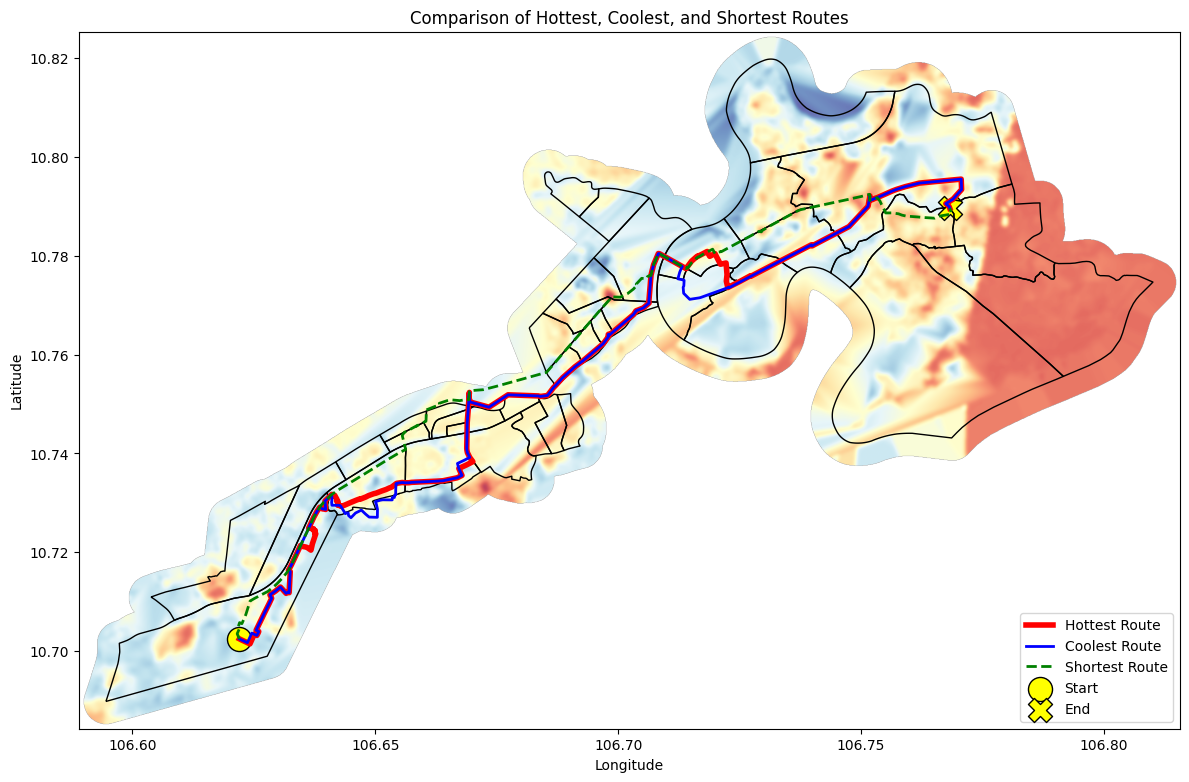

In [ ]:
def get_xy_coords(path, node_coords):
    xs = [node_coords[n][0] for n in path]
    ys = [node_coords[n][1] for n in path]
    return xs, ys

fig, ax = plt.subplots(figsize=(12, 12))

ax.imshow(
    smooth,
    extent = [raster_minx, raster_maxx, raster_miny, raster_maxy],
    cmap = "RdYlBu_r",
    alpha = 0.75,
    origin = "upper"
)

# Ward boundaries.
gdf_wards_original.boundary.plot(ax=ax, color = "black", linewidth = 1)

# Routes.
hx, hy = get_xy_coords(hottest_path, node_coords)
cx, cy = get_xy_coords(coolest_path, node_coords)
sx, sy = get_xy_coords(shortest_path, node_coords)

ax.plot(hx, hy, color = "red", linewidth = 4, label = "Hottest Route")
ax.plot(cx, cy, color = "blue", linewidth = 2, label = "Coolest Route")
ax.plot(sx, sy, color = "green", linewidth = 2, linestyle = "--", label = "Shortest Route")

# Start/end markers.
ax.scatter([start_coords[0]], [start_coords[1]],
           color = "yellow", edgecolor = "black", s = 300, label = "Start")
ax.scatter([end_coords[0]], [end_coords[1]],
           color = "yellow", marker = "X", edgecolor = "black", s = 300, label = "End")

ax.legend(loc = "lower right")
ax.set_title("Comparison of Hottest, Coolest, and Shortest Routes")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

# Helper to convert path to list of (lat, lon) for Folium.
def path_to_latlon(path, node_coords):
    return [(node_coords[n][1], node_coords[n][0]) for n in path]

# Center map between start and end.
center_lat = (start_coords[1] + end_coords[1]) / 2.0
center_lon = (start_coords[0] + end_coords[0]) / 2.0

route_map = folium.Map(location = [center_lat, center_lon], zoom_start = 13, tiles = "CartoDB Positron")

# Add routes.
folium.PolyLine(
    path_to_latlon(hottest_path, node_coords),
    color = "red",
    weight = 5,
    opacity = 0.8,
    tooltip = "Hottest Route"
).add_to(route_map)

folium.PolyLine(
    path_to_latlon(coolest_path, node_coords),
    color = "blue",
    weight = 5,
    opacity = 0.8,
    tooltip = "Coolest Route"
).add_to(route_map)

folium.PolyLine(
    path_to_latlon(shortest_path, node_coords),
    color="green",
    weight = 4,
    opacity = 0.8,
    dash_array = "10,5",
    tooltip = "Shortest Route"
).add_to(route_map)

# Add start/end markers.
folium.Marker(
    location = [start_coords[1], start_coords[0]],
    popup = "Start",
    icon = folium.Icon(color = "orange", icon = "play")
).add_to(route_map)

folium.Marker(
    location = [end_coords[1], end_coords[0]],
    popup = "End",
    icon = folium.Icon(color = "black", icon = "stop")
).add_to(route_map)

route_map

## MULTI-OD-PAIR EVALUATION

The single-route demo above only shows one OD pair, which cannot establish whether temperature differences are systematic or route-specific. This section samples 13 OD pairs across three distance classes (5 short, 5 medium, 3 long) and runs shortest/coolest/hottest routing on each to measure the distribution of temperature differences.

**Distance classes:**
- Short: 1-3 km straight-line (neighborhood trips).
- Medium: 3-8 km straight-line (cross-district trips).
- Long: 10+ km straight-line (full study area traversals).

In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine_dist(lon1, lat1, lon2, lat2):
    """
    Compute great-circle distance in meters between two lon/lat points.
    """
    R = 6371000  # Earth radius in meters.
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi / 2) ** 2 + cos(phi1) * cos(phi2) * sin(dlambda / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c


def compute_route_stats(G, path, node_lst_dict, node_coords_dict):
    """
    Compute distance (via haversine) and average LST for a route path.
    Returns (distance_m, avg_lst, max_lst).
    """
    temps = [node_lst_dict.get(n, np.nan) for n in path]
    coords = [node_coords_dict[n] for n in path]

    dist_m = 0.0
    for i in range(len(coords) - 1):
        dist_m += haversine_dist(coords[i][0], coords[i][1], coords[i + 1][0], coords[i + 1][1])

    return dist_m, np.nanmean(temps), np.nanmax(temps)

In [ ]:
# Sample OD pairs at different distance classes.
# Strategy: randomly sample node pairs, bin by straight-line distance,
# keep the first N that fall in each class.
import random

random.seed(42)
np.random.seed(42)

all_nodes = list(G_undirected.nodes)

# Target counts per distance class.
targets = {
    "short": {"min_km": 1.0, "max_km": 3.0, "n": 5, "pairs": []},
    "medium": {"min_km": 3.0, "max_km": 8.0, "n": 5, "pairs": []},
    "long": {"min_km": 10.0, "max_km": 50.0, "n": 3, "pairs": []},
}

# Sample candidate pairs until all bins are filled.
max_attempts = 50000
attempts = 0

while attempts < max_attempts:
    n1, n2 = random.sample(all_nodes, 2)
    c1 = node_coords[n1]
    c2 = node_coords[n2]
    d_km = haversine_dist(c1[0], c1[1], c2[0], c2[1]) / 1000.0

    for cls_name, cls_info in targets.items():
        if len(cls_info["pairs"]) < cls_info["n"]:
            if cls_info["min_km"] <= d_km <= cls_info["max_km"]:
                cls_info["pairs"].append((n1, n2, d_km))
                break

    # Check if all bins are full.
    if all(len(t["pairs"]) >= t["n"] for t in targets.values()):
        break

    attempts += 1

print("SAMPLED OD PAIRS")
for cls_name, cls_info in targets.items():
    print(f"  {cls_name}: {len(cls_info['pairs'])} pairs (target: {cls_info['n']})")

SAMPLED OD PAIRS
  short: 5 pairs (target: 5)
  medium: 5 pairs (target: 5)
  long: 3 pairs (target: 3)


In [ ]:
# Run routing for all OD pairs.
od_results = []

for cls_name, cls_info in targets.items():
    for pair_idx, (origin, destination, straight_km) in enumerate(cls_info["pairs"]):
        pair_label = f"{cls_name}_{pair_idx + 1}"

        # Shortest route.
        try:
            sp = nx.dijkstra_path(G_undirected, origin, destination, weight = "length")
            sp_dist, sp_avg, sp_max = compute_route_stats(G_undirected, sp, node_lst, node_coords)
        except nx.NetworkXNoPath:
            continue

        # Coolest route.
        try:
            cp = nx.dijkstra_path(G_undirected, origin, destination, weight = "cool_cost")
            cp_dist, cp_avg, cp_max = compute_route_stats(G_undirected, cp, node_lst, node_coords)
        except nx.NetworkXNoPath:
            cp_dist, cp_avg, cp_max = np.nan, np.nan, np.nan

        # Hottest route.
        try:
            hp = nx.dijkstra_path(G_undirected, origin, destination, weight = "hot_cost")
            hp_dist, hp_avg, hp_max = compute_route_stats(G_undirected, hp, node_lst, node_coords)
        except nx.NetworkXNoPath:
            hp_dist, hp_avg, hp_max = np.nan, np.nan, np.nan

        od_results.append({
            "pair": pair_label,
            "class": cls_name,
            "straight_km": round(straight_km, 2),
            "shortest_dist_m": round(sp_dist, 0),
            "shortest_avg_lst": round(sp_avg, 2),
            "coolest_dist_m": round(cp_dist, 0),
            "coolest_avg_lst": round(cp_avg, 2),
            "hottest_dist_m": round(hp_dist, 0),
            "hottest_avg_lst": round(hp_avg, 2),
            "cool_vs_short_lst": round(sp_avg - cp_avg, 2),
            "cool_vs_short_dist_pct": round((cp_dist - sp_dist) / sp_dist * 100, 1),
            "hot_vs_cool_lst": round(hp_avg - cp_avg, 2),
        })

df_od = pd.DataFrame(od_results)

print("MULTI-OD ROUTING RESULTS")
print(df_od.to_string(index = False))

MULTI-OD ROUTING RESULTS
    pair  class  straight_km  shortest_dist_m  shortest_avg_lst  coolest_dist_m  coolest_avg_lst  hottest_dist_m  hottest_avg_lst  cool_vs_short_lst  cool_vs_short_dist_pct  hot_vs_cool_lst
 short_1  short         2.51           3273.0             39.63          3535.0            39.68          3676.0            39.97              -0.05                     8.0             0.29
 short_2  short         2.03           2887.0             40.96          3391.0            40.78          3521.0            41.20               0.18                    17.5             0.42
 short_3  short         2.05           2208.0             39.89          2489.0            39.88          2491.0            39.89               0.01                    12.7             0.01
 short_4  short         1.45           1939.0             40.71          3041.0            40.08          2346.0            40.71               0.64                    56.8             0.63
 short_5  short         2

In [ ]:
# Summary statistics across all OD pairs.
print("SUMMARY STATISTICS ACROSS ALL OD PAIRS")
print(f"Total valid pairs: {len(df_od)}")
print("")

# Coolest vs shortest LST difference.
cool_diff = df_od["cool_vs_short_lst"]
print("Coolest route LST reduction vs shortest (C):")
print(f"  Mean: {cool_diff.mean():.3f}")
print(f"  Median: {cool_diff.median():.3f}")
print(f"  Min: {cool_diff.min():.3f}")
print(f"  Max: {cool_diff.max():.3f}")
print(f"  Std: {cool_diff.std():.3f}")
print("")

# Distance penalty for coolest route.
dist_penalty = df_od["cool_vs_short_dist_pct"]
print("Distance penalty for coolest route vs shortest (%):")
print(f"  Mean: {dist_penalty.mean():.1f}%")
print(f"  Median: {dist_penalty.median():.1f}%")
print(f"  Range: [{dist_penalty.min():.1f}%, {dist_penalty.max():.1f}%]")
print("")

# Hottest vs coolest spread.
hot_cool = df_od["hot_vs_cool_lst"]
print("Hottest vs coolest route LST spread (C):")
print(f"  Mean: {hot_cool.mean():.3f}")
print(f"  Median: {hot_cool.median():.3f}")
print(f"  Max: {hot_cool.max():.3f}")
print("")

# By distance class.
print("BY DISTANCE CLASS")
for cls_name in ["short", "medium", "long"]:
    subset = df_od[df_od["class"] == cls_name]
    if len(subset) > 0:
        print(f"  {cls_name} (n={len(subset)}): cool reduction = {subset['cool_vs_short_lst'].mean():.3f} C, dist penalty = {subset['cool_vs_short_dist_pct'].mean():.1f}%, hot-cool spread = {subset['hot_vs_cool_lst'].mean():.3f} C")

SUMMARY STATISTICS ACROSS ALL OD PAIRS
Total valid pairs: 13

Coolest route LST reduction vs shortest (C):
  Mean: 0.169
  Median: 0.160
  Min: -0.190
  Max: 0.640
  Std: 0.284

Distance penalty for coolest route vs shortest (%):
  Mean: 15.7%
  Median: 12.7%
  Range: [3.9%, 56.8%]

Hottest vs coolest route LST spread (C):
  Mean: 0.265
  Median: 0.210
  Max: 0.890

BY DISTANCE CLASS
  short (n=5): cool reduction = 0.118 C, dist penalty = 22.1%, hot-cool spread = 0.312 C
  medium (n=5): cool reduction = 0.154 C, dist penalty = 15.2%, hot-cool spread = 0.310 C
  long (n=3): cool reduction = 0.280 C, dist penalty = 5.7%, hot-cool spread = 0.113 C


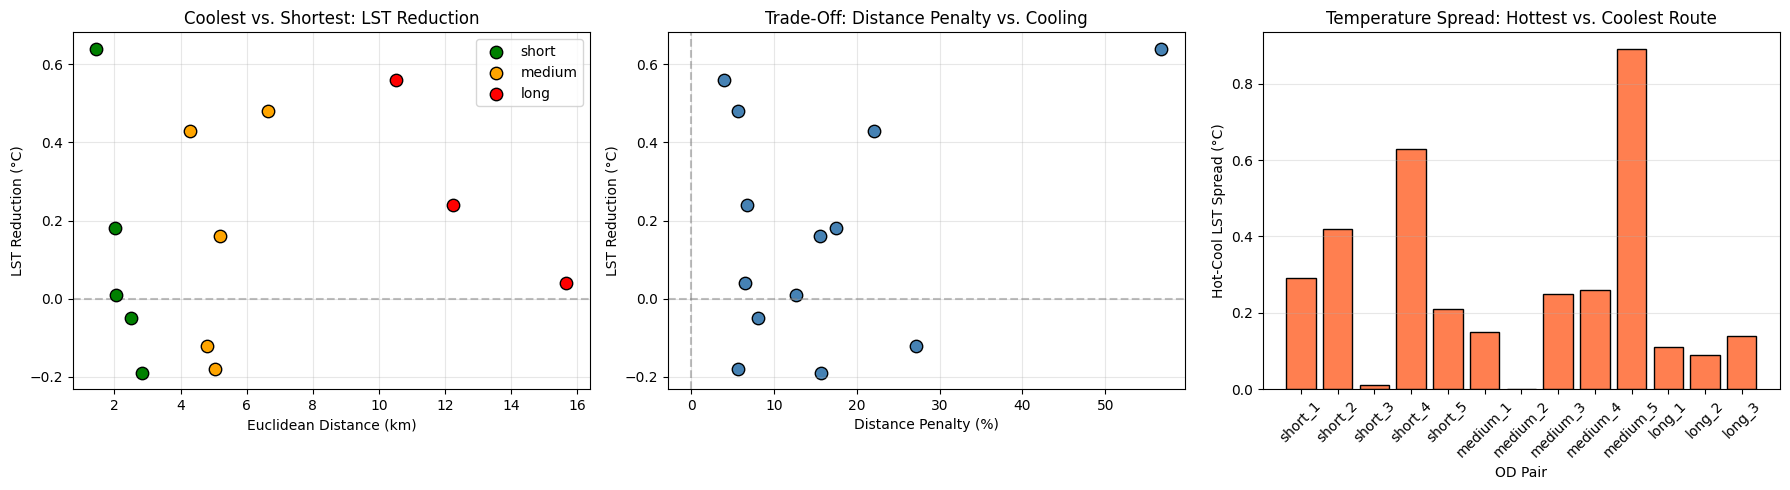

In [48]:
# Visualization of multi-OD results.
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# Panel 1: LST reduction (coolest vs shortest) by distance class.
for cls_name, color in [("short", "green"), ("medium", "orange"), ("long", "red")]:
    subset = df_od[df_od["class"] == cls_name]
    axes[0].scatter(subset["straight_km"], subset["cool_vs_short_lst"], c = color, s = 80, label = cls_name, edgecolor = "black", zorder = 5)

axes[0].axhline(0, color = "gray", linestyle = "--", alpha = 0.5)
axes[0].set_xlabel("Euclidean Distance (km)")
axes[0].set_ylabel("LST Reduction (°C)")
axes[0].set_title("Coolest vs. Shortest: LST Reduction")
axes[0].legend()
axes[0].grid(alpha = 0.3)

# Panel 2: Distance penalty vs LST reduction.
axes[1].scatter(df_od["cool_vs_short_dist_pct"], df_od["cool_vs_short_lst"], c = "steelblue", s = 80, edgecolor = "black")
axes[1].set_xlabel("Distance Penalty (%)")
axes[1].set_ylabel("LST Reduction (°C)")
axes[1].set_title("Trade-Off: Distance Penalty vs. Cooling")
axes[1].axhline(0, color = "gray", linestyle = "--", alpha = 0.5)
axes[1].axvline(0, color = "gray", linestyle = "--", alpha = 0.5)
axes[1].grid(alpha = 0.3)

# Panel 3: Hot-cool spread.
axes[2].bar(df_od["pair"], df_od["hot_vs_cool_lst"], color = "coral", edgecolor = "black")
axes[2].set_xlabel("OD Pair")
axes[2].set_ylabel("Hot-Cool LST Spread (°C)")
axes[2].set_title("Temperature Spread: Hottest vs. Coolest Route")
axes[2].tick_params(axis = "x", rotation = 45)
axes[2].grid(alpha = 0.3, axis = "y")

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "route_comparison_hybrid_model.png", dpi = 300, bbox_inches = "tight")
plt.show()